In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
"""
Paper-ready numerical experiments for prox-convex vs prox-gradient
on the product-of-quadratics problem:

    F(x) = R1(x) * R2(x)

Experiments:
  1. Single-run comparison (trajectory + convergence)
  2. Random initialization study (aggregate stats, boxplot, success rate)
  3. Condition-number sweep (iteration ratio vs kappa)
  4. Initial w_ptr sensitivity (aggregate over multiple x0)

IMPORTANT: Requires pc_solve.py, pc_parse.py in the same directory.
"""

import os
import sys
import time
import contextlib
import argparse
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import cvxpy as cp
import jax.numpy as jnp
from jax import jacfwd, jit

# ── Matplotlib style ────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'text.usetex': False,
})

C_PG  = '#d62728'   # red
C_PCX = '#1f77b4'   # blue

FIGDIR = 'figures/p3'
os.makedirs(FIGDIR, exist_ok=True)

from pc_solve import prox_convex

In [3]:
# ═══════════════════════════════════════════════════════════════
# Problem factory
# ═══════════════════════════════════════════════════════════════

def make_problem(condition_number=10.0, x0=None):

    prb_params = dict()

    c1 = np.array([5.0, 2.0])
    c2 = np.array([2.0, 1.0])
    P1 = np.diag([5.0, 5.0 / condition_number])
    P2 = np.diag([5.0 / condition_number, 5.0])

    R_dim, x_dim, C_dim = 2, 2, 1
    if x0 is None:
        x0 = np.array([0.0, 0.0])
    x_val = np.asarray(x0, dtype=float)
    y_val = np.array([1.0, 1.0], dtype=float)

    prb_params['R_dim'] = R_dim
    prb_params['x_dim'] = x_dim
    prb_params['C_dim'] = C_dim
    prb_params['x_val'] = x_val

    # Trust-region parameters (same for all methods)
    prb_params['adaptive_step'] = True
    prb_params['r_inc'] = 1.5
    prb_params['r_decr'] = 1.5
    prb_params['r0'] = 0.1
    prb_params['r1'] = 0.25
    prb_params['r2'] = 0.75

    prb_params['w_ptr_val'] = 0.01
    prb_params['term_val'] = 1e-8
    prb_params['term_dx'] = 1e-10
    prb_params['ITE'] = 500

    prb_params['solver_list'] = ['OSQP', 'QOCO', 'MOSEK', 'CLARABEL', 'ECOS'][1]
    prb_params['use_generated_code'] = False

    def convex_cp(x):
        return 0.0
    def convex_cp_np(x):
        return 0.0

    def h_cp(y2_val):
        return 0.0
    def h_jax(y2_val):
        return jnp.sum(y2_val) * 0.0
    def C(x_val):
        return jnp.array([jnp.dot(x_val, x_val) * 0.0])
    def hC(x_val):
        return h_jax(C(x_val))

    def R_cp(x_val):
        v1 = x_val - c1
        v2 = x_val - c2
        return 0.5 * cp.hstack([cp.quad_form(v1, P1), cp.quad_form(v2, P2)])

    def R_jax(x_val):
        v1 = x_val - c1
        v2 = x_val - c2
        return 0.5 * jnp.array([v1 @ P1 @ v1, v2 @ P2 @ v2])

    def s(y_val):
        return y_val[0] * y_val[1]
    def sR(x_val):
        return s(R_jax(x_val))
    def comp(x_val):
        return convex_cp_np(x_val) + hC(x_val) + sR(x_val)

    prb_params['hC'] = jit(hC).lower(x_val).compile()
    prb_params['g_hC'] = jit(jacfwd(hC)).lower(x_val).compile()
    prb_params['C'] = jit(C).lower(x_val).compile()
    prb_params['g_C'] = jit(jacfwd(C)).lower(x_val).compile()
    prb_params['sR'] = jit(sR).lower(x_val).compile()
    prb_params['g_sR'] = jit(jacfwd(sR)).lower(x_val).compile()
    prb_params['g_s'] = jit(jacfwd(s)).lower(y_val).compile()
    prb_params['R_jax'] = jit(R_jax).lower(x_val).compile()
    prb_params['comp'] = jit(comp).lower(x_val).compile()

    prb_params['convex_cp'] = convex_cp
    prb_params['h_cp'] = h_cp
    prb_params['R_cp'] = R_cp
    prb_params['_c1'] = c1
    prb_params['_c2'] = c2
    prb_params['_P1'] = P1
    prb_params['_P2'] = P2
    prb_params['_kappa'] = condition_number

    return prb_params

In [4]:
# ═══════════════════════════════════════════════════════════════
# Helpers
# ═══════════════════════════════════════════════════════════════

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, 'w') as fnull:
        old = sys.stdout
        sys.stdout = fnull
        try:
            yield
        finally:
            sys.stdout = old


def run_single(params, alg_type, w0=None, verbose=True):
    if w0 is not None:
        params['w_ptr_val'] = w0
    if verbose:
        return prox_convex(prb_params=params, alg_type=alg_type)
    else:
        with suppress_stdout():
            return prox_convex(prb_params=params, alg_type=alg_type)


def count_iters(res):
    return len(res['x_val_list']) - 1

def count_solves(res):
    return len(res['times'])

def total_time(res):
    return res['scp_solve_time']

def avg_solve_time(res):
    return np.mean(res['times']) if res['times'] else 0.0

def safe_log(arr, eps=1e-20):
    return np.log(np.maximum(np.asarray(arr, dtype=float), eps))

In [5]:
# ═══════════════════════════════════════════════════════════════
# Experiment 1: Single-run comparison
# ═══════════════════════════════════════════════════════════════

def experiment_1(w0=0.01, x0=None):
    print('\n' + '=' * 70)
    print('EXPERIMENT 1: Single-run comparison')
    print('=' * 70)

    params = make_problem(condition_number=10.0, x0=x0)
    c1, c2 = params['_c1'], params['_c2']

    print(f"\nx0 = {params['x_val']},  w0 = {w0}")

    print('\n--- prox-gradient ---')
    res_pg = run_single(params, 'prox_gradient', w0=w0)
    print('\n--- prox-convex ---')
    res_pcx = run_single(params, 'prox_convex', w0=w0)

    # ── Summary ──
    print('\n' + '-' * 80)
    fmt = ("{:16s}  acc={:3d}  solves={:3d}  F*={:10.2e}  "
           "time={:.4f}s  avg/solve={:.5f}s  x*=[{:.3f}, {:.3f}]")
    for name, res in [('prox-gradient', res_pg), ('prox-convex', res_pcx)]:
        xf = res['x_val_list'][-1]
        print(fmt.format(name, count_iters(res), count_solves(res),
                         float(res['J_list'][-1]), total_time(res),
                         avg_solve_time(res), xf[0], xf[1]))

    # ── Figure 1: Convergence (2x2) ──
    fig, axs = plt.subplots(2, 2, figsize=(9, 6))

    J_pg = np.asarray(res_pg['J_list'], dtype=float)
    J_pcx = np.asarray(res_pcx['J_list'], dtype=float)

    axs[0, 0].plot(safe_log(J_pg), c=C_PG, label='prox-gradient')
    axs[0, 0].plot(safe_log(J_pcx), c=C_PCX, label='prox-convex')
    axs[0, 0].set_ylabel(r'$\log F(x_k)$')
    axs[0, 0].set_xlabel('Accepted iteration')
    axs[0, 0].legend()
    axs[0, 0].set_title('(a) Objective (log scale)')
    axs[0, 0].grid(True, alpha=0.3)

    axs[0, 1].plot(J_pg, c=C_PG, label='prox-gradient')
    axs[0, 1].plot(J_pcx, c=C_PCX, label='prox-convex')
    axs[0, 1].set_ylabel(r'$F(x_k)$')
    axs[0, 1].set_xlabel('Accepted iteration')
    axs[0, 1].legend()
    axs[0, 1].set_title('(b) Objective (linear scale)')
    axs[0, 1].grid(True, alpha=0.3)

    dx_pg = np.asarray(res_pg['dx_list'], dtype=float)
    dx_pcx = np.asarray(res_pcx['dx_list'], dtype=float)
    axs[1, 0].plot(safe_log(dx_pg), c=C_PG, label='prox-gradient')
    axs[1, 0].plot(safe_log(dx_pcx), c=C_PCX, label='prox-convex')
    axs[1, 0].set_ylabel(r'$\log \|x_{k+1} - x_k\|$')
    axs[1, 0].set_xlabel('Accepted iteration')
    axs[1, 0].legend()
    axs[1, 0].set_title(r'(c) Step size')
    axs[1, 0].grid(True, alpha=0.3)

    w_pg = np.asarray(res_pg['w_ptr_val_list'], dtype=float)
    w_pcx = np.asarray(res_pcx['w_ptr_val_list'], dtype=float)
    axs[1, 1].semilogy(w_pg, c=C_PG, label='prox-gradient')
    axs[1, 1].semilogy(w_pcx, c=C_PCX, label='prox-convex')
    axs[1, 1].set_ylabel(r'$\mu_k$')
    axs[1, 1].set_xlabel('Accepted iteration')
    axs[1, 1].legend()
    axs[1, 1].set_title(r'(d) Adaptive proximal weight $\mu_k$')
    axs[1, 1].grid(True, alpha=0.3)

    fig.suptitle(r'Product of quadratics:  $F = R_1 \cdot R_2$,  $\kappa = 10$',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/convergence.pdf')
    fig.savefig(f'{FIGDIR}/convergence.png')
    print(f'\nSaved {FIGDIR}/convergence')
    plt.show()

    # ── Figure 2: Trajectory ──
    fig2, ax2 = plt.subplots(figsize=(7, 4.5))
    x1g = np.linspace(-1.5, 6.5, 301)
    x2g = np.linspace(-0.5, 3.0, 301)
    X1, X2 = np.meshgrid(x1g, x2g)
    Z = np.zeros_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            Z[i, j] = float(np.asarray(params['comp'](
                np.array([X1[i, j], X2[i, j]]))))

    levels = np.concatenate([[0.01, 0.1, 0.5], np.exp(np.arange(0, 6.0, 0.5))])
    levels = np.sort(np.unique(levels))
    CS = ax2.contour(X1, X2, Z, levels=levels, cmap='viridis', linewidths=0.8)
    ax2.clabel(CS, inline=True, fontsize=7, fmt='%.1f')

    xv_pg = np.asarray(res_pg['x_val_list'], dtype=float)
    xv_pcx = np.asarray(res_pcx['x_val_list'], dtype=float)
    ax2.plot(xv_pg[:, 0], xv_pg[:, 1], '-o', c=C_PG, ms=4, lw=1.5,
             label=f'prox-gradient ({count_iters(res_pg)} iters)', zorder=3)
    ax2.plot(xv_pcx[:, 0], xv_pcx[:, 1], '-s', c=C_PCX, ms=4, lw=1.5,
             label=f'prox-convex ({count_iters(res_pcx)} iters)', zorder=3)
    ax2.scatter(*c1, marker='*', s=200, c='gold', edgecolors='k', zorder=5)
    ax2.scatter(*c2, marker='*', s=200, c='gold', edgecolors='k', zorder=5)
    ax2.annotate(r'$c_1$', c1, textcoords='offset points', xytext=(8, -8), fontsize=11)
    ax2.annotate(r'$c_2$', c2, textcoords='offset points', xytext=(8, -8), fontsize=11)

    ax2.set_xlabel(r'$x_1$')
    ax2.set_ylabel(r'$x_2$')
    ax2.set_title(r'Iterate trajectories over level sets of $F$')
    ax2.legend(loc='upper left')
    ax2.set_xlim(-1.5, 6.5)
    ax2.set_ylim(-0.5, 3.0)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    fig2.savefig(f'{FIGDIR}/trajectory.pdf')
    fig2.savefig(f'{FIGDIR}/trajectory.png')
    print(f'Saved {FIGDIR}/trajectory')
    plt.show()

In [6]:
# ═══════════════════════════════════════════════════════════════
# Experiment 2: Random initialization study
# ═══════════════════════════════════════════════════════════════

def experiment_2(N=50, seed=42, kappa=10.0, w0=0.01):
    print('\n' + '=' * 70)
    print(f'EXPERIMENT 2: Random initialization study  (N={N}, kappa={kappa})')
    print('=' * 70)

    rng = np.random.default_rng(seed)
    x0s = rng.uniform(low=[-2, -2], high=[8, 5], size=(N, 2))

    iters_pg  = np.zeros(N);  iters_pcx = np.zeros(N)
    solves_pg = np.zeros(N);  solves_pcx = np.zeros(N)
    times_pg  = np.zeros(N);  times_pcx = np.zeros(N)
    conv_pg   = np.zeros(N, dtype=bool)
    conv_pcx  = np.zeros(N, dtype=bool)

    for i, x0 in enumerate(x0s):
        print(f'\r  Run {i+1}/{N}  x0=[{x0[0]:+.2f}, {x0[1]:+.2f}]', end='', flush=True)
        params = make_problem(condition_number=kappa, x0=x0)

        res_pg  = run_single(params, 'prox_gradient', w0=w0, verbose=False)
        res_pcx = run_single(params, 'prox_convex',   w0=w0, verbose=False)

        iters_pg[i]  = count_iters(res_pg);   iters_pcx[i] = count_iters(res_pcx)
        solves_pg[i] = count_solves(res_pg);   solves_pcx[i] = count_solves(res_pcx)
        times_pg[i]  = total_time(res_pg);     times_pcx[i] = total_time(res_pcx)
        conv_pg[i]   = res_pg['converged'];    conv_pcx[i]  = res_pcx['converged']

    print()

    # ── Success rates ──
    n_conv_pg  = int(np.sum(conv_pg));   n_fail_pg  = N - n_conv_pg
    n_conv_pcx = int(np.sum(conv_pcx));  n_fail_pcx = N - n_conv_pcx

    print(f"\nConvergence:")
    print(f"  prox-gradient:  {n_conv_pg}/{N} converged,  {n_fail_pg} hit max-iter limit")
    print(f"  prox-convex:    {n_conv_pcx}/{N} converged,  {n_fail_pcx} hit max-iter limit")

    # ── Stats over runs where both converged ──
    mask = conv_pg & conv_pcx
    n_both = int(np.sum(mask))
    print(f"  Both converged: {n_both}/{N}")

    if n_both > 0:
        ratio_iters = iters_pg[mask] / np.maximum(iters_pcx[mask], 1)
        ratio_times = times_pg[mask] / np.maximum(times_pcx[mask], 1e-9)

        print(f"\n{'Metric':<24s}  {'prox-gradient':>22s}  {'prox-convex':>22s}  {'ratio':>8s}")
        print('-' * 82)
        for label, a, b, r in [
            ('Accepted iters', iters_pg[mask], iters_pcx[mask], ratio_iters),
            ('Total solves',   solves_pg[mask], solves_pcx[mask],
             solves_pg[mask]/np.maximum(solves_pcx[mask], 1)),
            ('Wall time (ms)', times_pg[mask]*1e3, times_pcx[mask]*1e3, ratio_times),
        ]:
            print(f"{label:<24s}  "
                  f"med={np.median(a):7.1f} [{np.percentile(a,25):6.1f},{np.percentile(a,75):6.1f}]  "
                  f"med={np.median(b):7.1f} [{np.percentile(b,25):6.1f},{np.percentile(b,75):6.1f}]  "
                  f"{np.median(r):8.2f}")

    # ── Figure: Box plot (iterations + time) ──
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))

    bp1 = axes[0].boxplot([iters_pg[mask], iters_pcx[mask]],
                          labels=['prox-gradient', 'prox-convex'],
                          patch_artist=True, widths=0.5,
                          medianprops=dict(color='black', linewidth=2))
    bp1['boxes'][0].set_facecolor(C_PG);  bp1['boxes'][0].set_alpha(0.5)
    bp1['boxes'][1].set_facecolor(C_PCX); bp1['boxes'][1].set_alpha(0.5)
    axes[0].set_ylabel('Accepted iterations')
    axes[0].set_title(f'(a) Iteration count')
    axes[0].grid(True, alpha=0.3, axis='y')

    bp2 = axes[1].boxplot([times_pg[mask]*1000, times_pcx[mask]*1000],
                          labels=['prox-gradient', 'prox-convex'],
                          patch_artist=True, widths=0.5,
                          medianprops=dict(color='black', linewidth=2))
    bp2['boxes'][0].set_facecolor(C_PG);  bp2['boxes'][0].set_alpha(0.5)
    bp2['boxes'][1].set_facecolor(C_PCX); bp2['boxes'][1].set_alpha(0.5)
    axes[1].set_ylabel('Wall-clock time (ms)')
    axes[1].set_title(f'(b) Solve time')
    axes[1].grid(True, alpha=0.3, axis='y')

    fig.suptitle(rf'Distribution over $N={n_both}$ random starts  ($\kappa={kappa:.0f}$)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/boxplot.pdf')
    fig.savefig(f'{FIGDIR}/boxplot.png')
    print(f'\nSaved {FIGDIR}/boxplot')
    plt.show()

In [7]:
# ═══════════════════════════════════════════════════════════════
# Experiment 3: Condition-number sweep
# ═══════════════════════════════════════════════════════════════

def experiment_3(N_per_kappa=20, seed=0, w0=0.01):
    print('\n' + '=' * 70)
    print('EXPERIMENT 3: Condition-number sweep')
    print('=' * 70)

    kappas = [1, 2, 5, 10, 20, 50, 100, 200, 500]
    rng = np.random.default_rng(seed)
    x0s = rng.uniform(low=[-2, -2], high=[8, 5], size=(N_per_kappa, 2))

    med_pg = [];  med_pcx = []
    q25_ratio = [];  med_ratio = [];  q75_ratio = []
    med_time_pg = [];  med_time_pcx = []

    hdr = (f"{'kappa':>6s}  {'pg_med':>7s}  {'pcx_med':>8s}  {'ratio':>7s}  "
           f"{'pg_time':>10s}  {'pcx_time':>10s}  {'time_rat':>9s}  "
           f"{'conv_pg':>8s}  {'conv_pcx':>9s}")
    print(f"\n{hdr}")
    print('-' * len(hdr))

    for kappa in kappas:
        ite_pg = [];  ite_pcx = [];  t_pg = [];  t_pcx = []
        n_c_pg = 0;  n_c_pcx = 0

        for x0 in x0s:
            params = make_problem(condition_number=kappa, x0=x0)
            r_pg  = run_single(params, 'prox_gradient', w0=w0, verbose=False)
            r_pcx = run_single(params, 'prox_convex',   w0=w0, verbose=False)
            ite_pg.append(count_iters(r_pg));   ite_pcx.append(count_iters(r_pcx))
            t_pg.append(total_time(r_pg));       t_pcx.append(total_time(r_pcx))
            n_c_pg += r_pg['converged'];         n_c_pcx += r_pcx['converged']

        ite_pg = np.array(ite_pg);  ite_pcx = np.array(ite_pcx)
        t_pg = np.array(t_pg);      t_pcx = np.array(t_pcx)
        ratios = ite_pg / np.maximum(ite_pcx, 1)

        med_pg.append(np.median(ite_pg));       med_pcx.append(np.median(ite_pcx))
        q25_ratio.append(np.percentile(ratios, 25))
        med_ratio.append(np.median(ratios))
        q75_ratio.append(np.percentile(ratios, 75))
        med_time_pg.append(np.median(t_pg));    med_time_pcx.append(np.median(t_pcx))

        print(f"{kappa:6.0f}  {np.median(ite_pg):7.0f}  {np.median(ite_pcx):8.0f}  "
              f"{np.median(ratios):7.2f}  "
              f"{np.median(t_pg)*1000:8.1f}ms  {np.median(t_pcx)*1000:8.1f}ms  "
              f"{np.median(t_pg/np.maximum(t_pcx, 1e-9)):9.2f}  "
              f"{n_c_pg:4d}/{N_per_kappa:d}  {n_c_pcx:5d}/{N_per_kappa:d}")

    kappas_arr = np.array(kappas, dtype=float)
    med_ratio_arr = np.array(med_ratio)
    q25_arr = np.array(q25_ratio);  q75_arr = np.array(q75_ratio)

    # ── Figure ──
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].fill_between(kappas_arr, q25_arr, q75_arr, alpha=0.25, color=C_PCX)
    axes[0].plot(kappas_arr, med_ratio_arr, '-o', c=C_PCX, label='median ratio (pg / pcx)')
    axes[0].axhline(1.0, ls='--', c='gray', lw=1)
    axes[0].set_xscale('log');  axes[0].set_xlabel(r'Condition number $\kappa$')
    axes[0].set_ylabel('Iteration ratio  (pg / pcx)')
    axes[0].set_title('(a) Speedup vs condition number')
    axes[0].legend();  axes[0].grid(True, alpha=0.3)

    axes[1].plot(kappas_arr, med_pg, '-o', c=C_PG, label='prox-gradient (median)')
    axes[1].plot(kappas_arr, med_pcx, '-s', c=C_PCX, label='prox-convex (median)')
    axes[1].set_xscale('log');  axes[1].set_xlabel(r'Condition number $\kappa$')
    axes[1].set_ylabel('Accepted iterations')
    axes[1].set_title('(b) Iterations vs condition number')
    axes[1].legend();  axes[1].grid(True, alpha=0.3)

    fig.suptitle(rf'Effect of inner curvature ($N={N_per_kappa}$ random starts per $\kappa$)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/kappa_sweep.pdf')
    fig.savefig(f'{FIGDIR}/kappa_sweep.png')
    print(f'\nSaved {FIGDIR}/kappa_sweep')
    plt.show()

In [8]:
# ═══════════════════════════════════════════════════════════════
# Experiment 4: w0 sensitivity (aggregate)
# ═══════════════════════════════════════════════════════════════

def experiment_4(kappa=10.0, N=20, seed=99):
    print('\n' + '=' * 70)
    print(f'EXPERIMENT 4: w0 sensitivity (aggregate, N={N} per w0)')
    print('=' * 70)

    w0_list = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
    rng = np.random.default_rng(seed)
    x0s = rng.uniform(low=[-2, -2], high=[8, 5], size=(N, 2))

    med_iters_pg = [];  med_iters_pcx = []
    med_solves_pg = []; med_solves_pcx = []
    med_time_pg = [];   med_time_pcx = []

    hdr = (f"{'w0':>8s}  {'pg iters':>10s}  {'pg solves':>10s}  {'pg time':>10s}  "
           f"{'pcx iters':>10s}  {'pcx solves':>11s}  {'pcx time':>10s}  "
           f"{'rat(i)':>7s}  {'rat(t)':>7s}")
    print(f"\n{hdr}")
    print('-' * len(hdr))

    for w0 in w0_list:
        pg_i = [];  pcx_i = [];  pg_s = [];  pcx_s = [];  pg_t = [];  pcx_t = []

        for x0 in x0s:
            params = make_problem(condition_number=kappa, x0=x0)
            r_pg  = run_single(params, 'prox_gradient', w0=w0, verbose=False)
            r_pcx = run_single(params, 'prox_convex',   w0=w0, verbose=False)
            pg_i.append(count_iters(r_pg));   pcx_i.append(count_iters(r_pcx))
            pg_s.append(count_solves(r_pg));   pcx_s.append(count_solves(r_pcx))
            pg_t.append(total_time(r_pg));     pcx_t.append(total_time(r_pcx))

        pg_i = np.array(pg_i);   pcx_i = np.array(pcx_i)
        pg_s = np.array(pg_s);   pcx_s = np.array(pcx_s)
        pg_t = np.array(pg_t);   pcx_t = np.array(pcx_t)

        mi_pg = np.median(pg_i);   mi_pcx = np.median(pcx_i)
        ms_pg = np.median(pg_s);   ms_pcx = np.median(pcx_s)
        mt_pg = np.median(pg_t);   mt_pcx = np.median(pcx_t)

        med_iters_pg.append(mi_pg);   med_iters_pcx.append(mi_pcx)
        med_solves_pg.append(ms_pg);  med_solves_pcx.append(ms_pcx)
        med_time_pg.append(mt_pg);    med_time_pcx.append(mt_pcx)

        ri = mi_pg / max(mi_pcx, 1)
        rt = mt_pg / max(mt_pcx, 1e-9)
        print(f"{w0:8.2f}  {mi_pg:10.0f}  {ms_pg:10.0f}  {mt_pg*1000:8.1f}ms  "
              f"{mi_pcx:10.0f}  {ms_pcx:11.0f}  {mt_pcx*1000:8.1f}ms  "
              f"{ri:7.2f}  {rt:7.2f}")

    # ── Figure ──
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].semilogx(w0_list, med_iters_pg, '-o', c=C_PG, label='prox-gradient')
    axes[0].semilogx(w0_list, med_iters_pcx, '-s', c=C_PCX, label='prox-convex')
    axes[0].set_xlabel(r'Initial $\mu_0$');  axes[0].set_ylabel('Median accepted iterations')
    axes[0].set_title(r'(a) Accepted iterations');  axes[0].legend();  axes[0].grid(True, alpha=0.3)

    axes[1].semilogx(w0_list, med_solves_pg, '-o', c=C_PG, label='prox-gradient')
    axes[1].semilogx(w0_list, med_solves_pcx, '-s', c=C_PCX, label='prox-convex')
    axes[1].set_xlabel(r'Initial $\mu_0$');  axes[1].set_ylabel('Median total solves')
    axes[1].set_title(r'(b) Total solves');  axes[1].legend();  axes[1].grid(True, alpha=0.3)

    axes[2].semilogx(w0_list, np.array(med_time_pg)*1000, '-o', c=C_PG, label='prox-gradient')
    axes[2].semilogx(w0_list, np.array(med_time_pcx)*1000, '-s', c=C_PCX, label='prox-convex')
    axes[2].set_xlabel(r'Initial $\mu_0$');  axes[2].set_ylabel('Median wall time (ms)')
    axes[2].set_title(r'(c) Wall-clock time');  axes[2].legend();  axes[2].grid(True, alpha=0.3)

    fig.suptitle(rf'Sensitivity to $\mu_0$  ($\kappa={kappa:.0f}$, $N={N}$ starts per $\mu_0$)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(f'{FIGDIR}/w0_sensitivity.pdf')
    fig.savefig(f'{FIGDIR}/w0_sensitivity.png')
    print(f'\nSaved {FIGDIR}/w0_sensitivity')
    plt.show()


EXPERIMENT 1: Single-run comparison

x0 = [0. 0.],  w0 = 0.01

--- prox-gradient ---
Problem parameters:  dict_keys(['sR', 'grad_sR', 'hC', 'grad_hC', 'w_ptr', 'xk'])
DPP:  True
Iter 0, J_xk: 222.2500, J_diff: -1.360444e+17, L_diff: 3.146050e+06, Ratio: -43242935656.0343, dx: 1.773709e+04, w_ptr: 0.0100, dt: 0.0101
-----------------------------------Reject-----------------------------------
Iter 0, J_xk: 222.2500, J_diff: -2.685792e+16, L_diff: 2.097367e+06, Ratio: -12805541819.3850, dx: 1.182473e+04, w_ptr: 0.0150, dt: 0.0007
-----------------------------------Reject-----------------------------------
Iter 0, J_xk: 222.2500, J_diff: -5.300800e+15, L_diff: 1.398244e+06, Ratio: -3791039785.2130, dx: 7.883156e+03, w_ptr: 0.0225, dt: 0.0006
-----------------------------------Reject-----------------------------------
Iter 0, J_xk: 222.2500, J_diff: -1.045749e+15, L_diff: 9.321630e+05, Ratio: -1121852238.0344, dx: 5.255438e+03, w_ptr: 0.0338, dt: 0.0006
-----------------------------------R

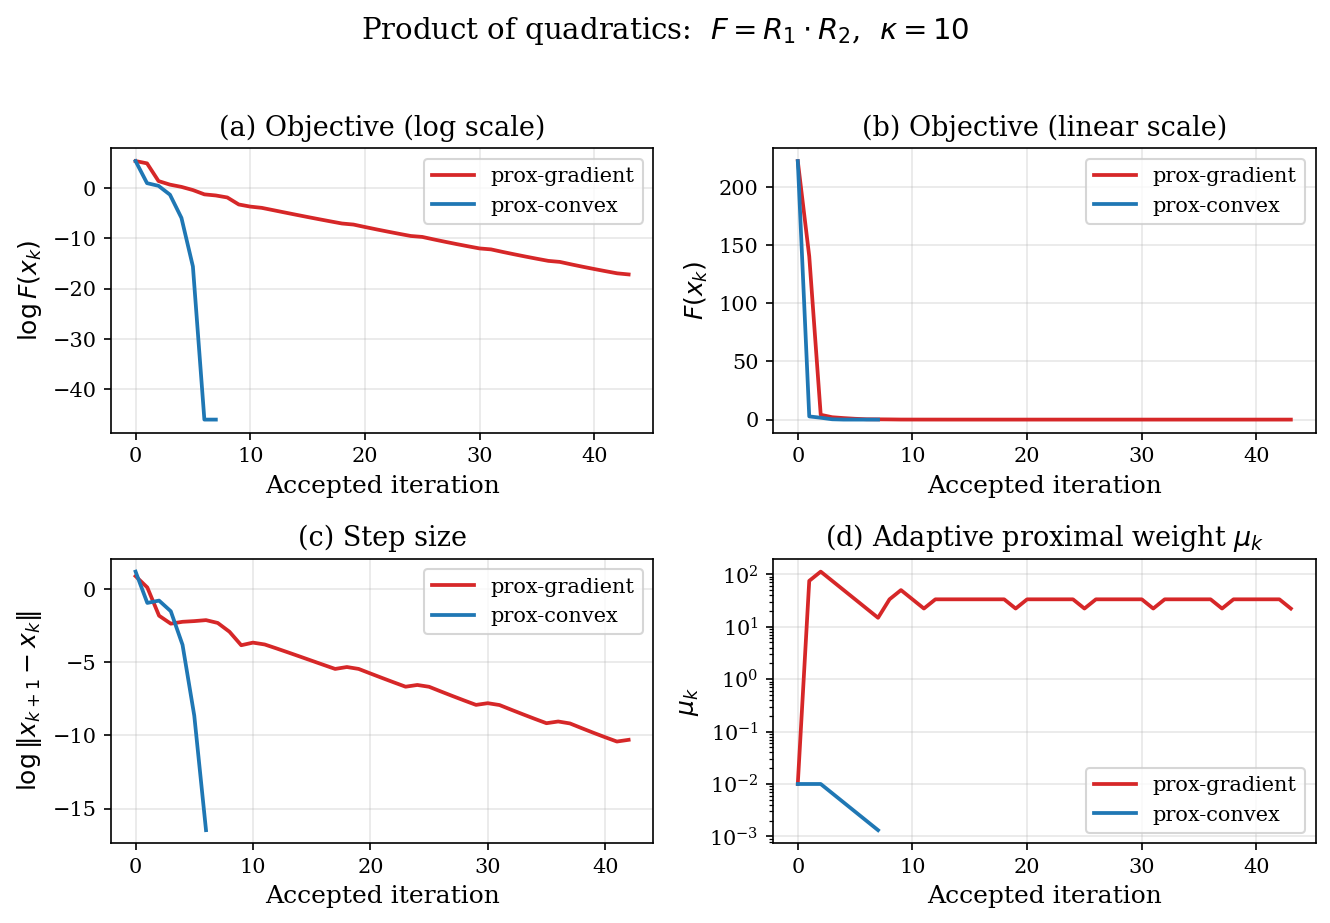

Saved figures/p3/trajectory


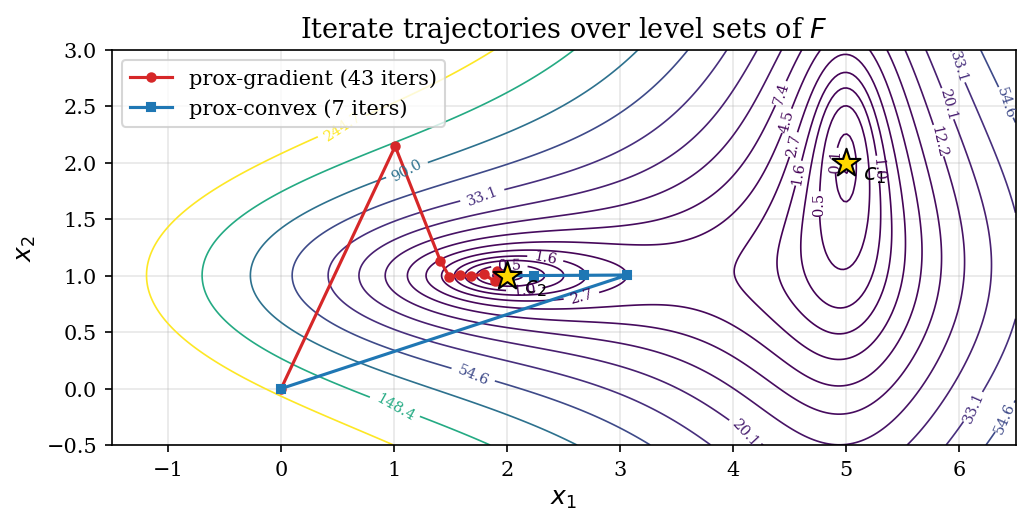

In [9]:
experiment_1(w0=0.01, x0=np.array([0.0, 0.0]))


EXPERIMENT 2: Random initialization study  (N=50, kappa=10.0)
  Run 50/50  x0=[-0.82, +4.73]

Convergence:
  prox-gradient:  50/50 converged,  0 hit max-iter limit
  prox-convex:    50/50 converged,  0 hit max-iter limit
  Both converged: 50/50

Metric                             prox-gradient             prox-convex     ratio
----------------------------------------------------------------------------------
Accepted iters            med=   46.5 [  44.0,  48.0]  med=    7.0 [   6.0,   8.0]      6.69
Total solves              med=   72.0 [  68.0,  78.0]  med=    7.0 [   6.0,   8.0]     10.14
Wall time (ms)            med=   58.9 [  51.6,  65.2]  med=    9.6 [   8.3,  10.6]      6.32


/var/folders/11/hzqn0f2j39lc0y5rrxhy48600000gn/T/ipykernel_59014/3931291042.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot([iters_pg[mask], iters_pcx[mask]],
/var/folders/11/hzqn0f2j39lc0y5rrxhy48600000gn/T/ipykernel_59014/3931291042.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot([times_pg[mask]*1000, times_pcx[mask]*1000],



Saved figures/p3/boxplot


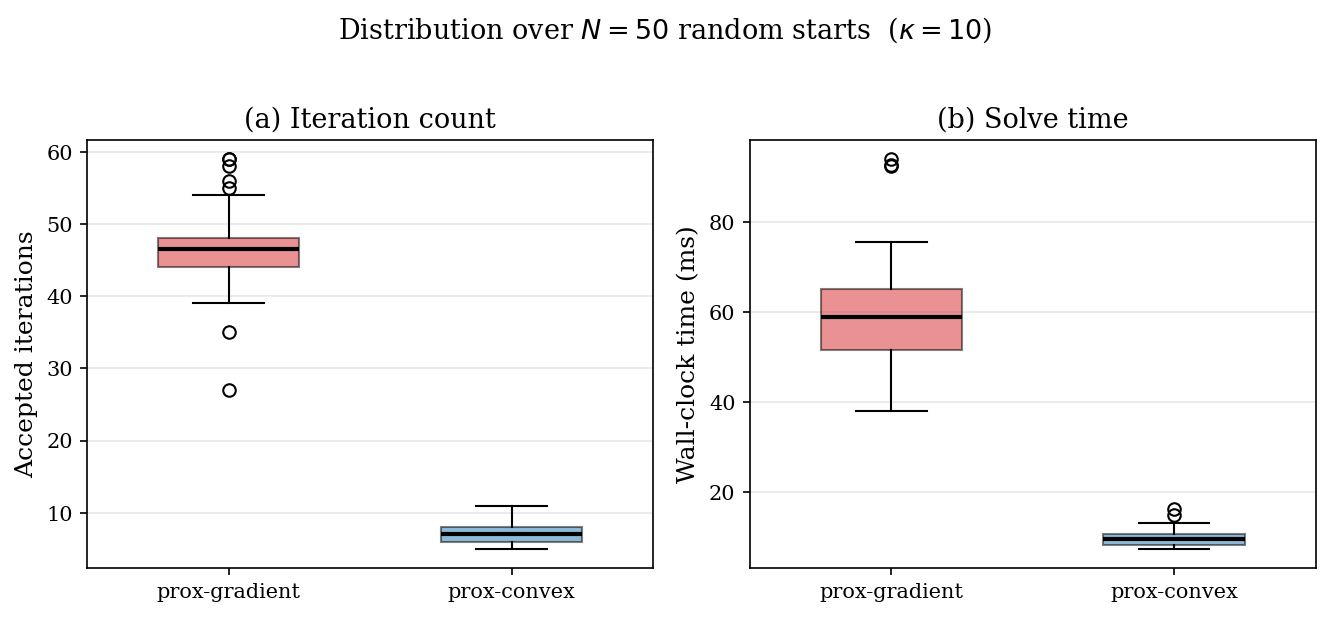

In [10]:
experiment_2(N=50, kappa=10.0, w0=0.01)


EXPERIMENT 3: Condition-number sweep

 kappa   pg_med   pcx_med    ratio     pg_time    pcx_time   time_rat   conv_pg   conv_pcx
------------------------------------------------------------------------------------------
     1       14         6     2.31      33.0ms       9.1ms       3.57    50/50     50/50
     2       19         6     3.07      36.1ms       8.6ms       4.18    50/50     50/50
     5       27         6     4.00      39.6ms       9.3ms       4.54    50/50     50/50
    10       47         7     6.46      61.5ms       9.8ms       6.19    50/50     50/50
    20       82         8     9.89      94.2ms      10.8ms       8.54    50/50     50/50
    50      176        14    14.99     191.2ms      14.9ms      13.61    50/50     50/50
   100      258        10    27.20     269.4ms      11.1ms      20.35    50/50     50/50
   200      413         6    61.43     394.3ms       8.6ms      40.67    32/50     50/50
   500      500         6    83.33     515.9ms       9.3ms      47.

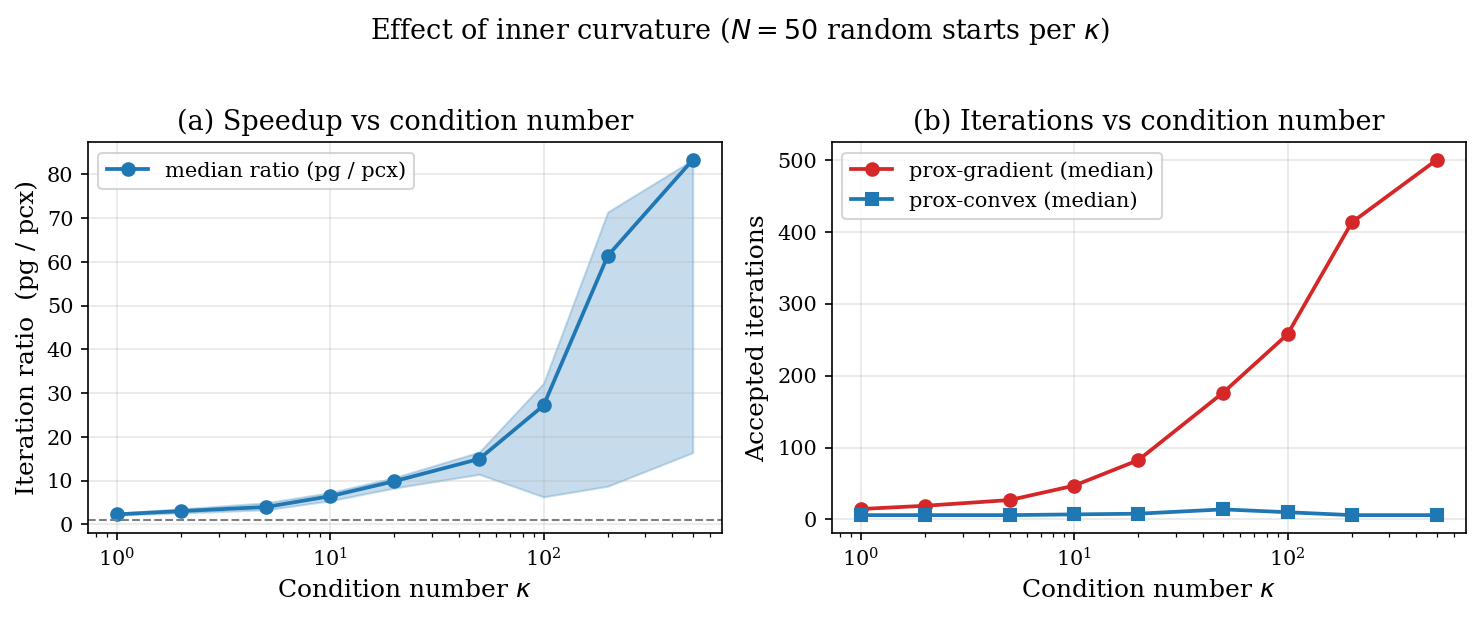

In [11]:
experiment_3(N_per_kappa=50, w0=0.01)


EXPERIMENT 4: w0 sensitivity (aggregate, N=20 per w0)

      w0    pg iters   pg solves     pg time   pcx iters   pcx solves    pcx time   rat(i)   rat(t)
---------------------------------------------------------------------------------------------------
    0.01          48          74      69.3ms           7            7      11.5ms     6.86     6.03
    0.10          44          66      54.3ms           8            8      10.2ms     5.93     5.33
    1.00          45          66      55.4ms          10           10      11.9ms     4.50     4.67
   10.00          47          58      50.2ms          14           14      14.7ms     3.48     3.41
  100.00          46          52      48.4ms          17           17      18.5ms     2.71     2.61
 1000.00          48          62      56.4ms          22           22      24.1ms     2.13     2.35

Saved figures/p3/w0_sensitivity


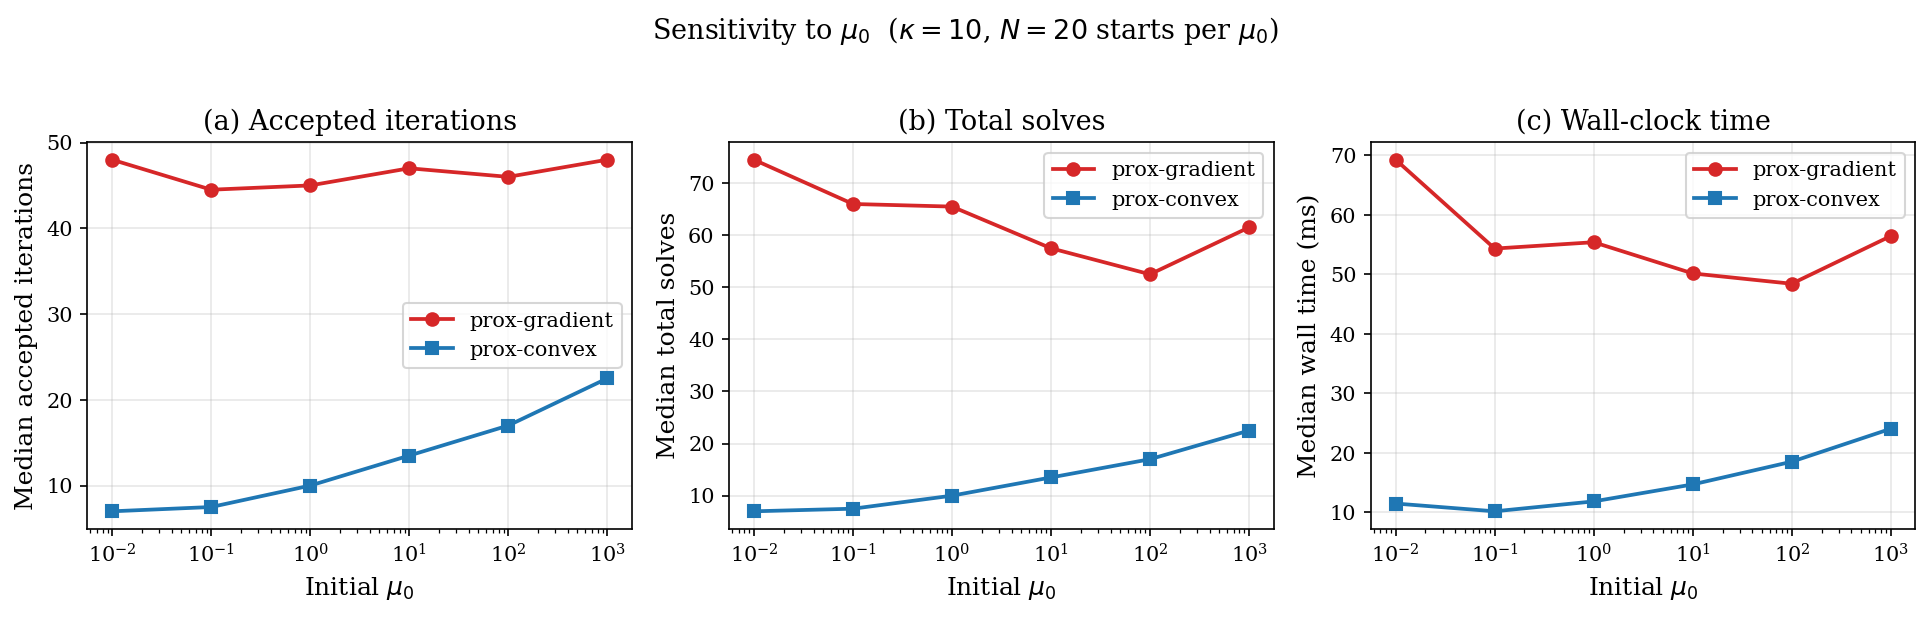

In [12]:
experiment_4(kappa=10.0, N=20)